<a href="https://colab.research.google.com/github/ojaspaul123/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Kaggle Dataset**

In [2]:
!pip install kaggle

In [6]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
!unzip imdb-dataset-of-50k-movie-reviews.zip

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 147MB/s]

Archive:  imdb-dataset-of-50k-movie-reviews.zip
replace IMDB Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

**Load the Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('IMDB Dataset.csv')
df.head()

Saving IMDB Dataset.csv to IMDB Dataset.csv


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
df.shape

(50000, 2)

**Text Preprocessing**

In [8]:
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_review(review):
  review = html.unescape(review)
  review = re.sub(r'<.*?>', '', review)
  review = review.lower()

  review = re.sub(r'[^a-zA-Z0-9\s]', '', review)
  review = re.sub(r'\s+', ' ', review)
  review = review.strip()
  words = review.split()

  clean_words = [stemmer.stem(word) for word in words if word not in stop_words]

  return clean_words

df['review'] = df['review'].apply(clean_review)

df



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,review,sentiment
0,"[one, review, mention, watch, 1, oz, episod, y...",positive
1,"[wonder, littl, product, film, techniqu, unass...",positive
2,"[thought, wonder, way, spend, time, hot, summe...",positive
3,"[basic, there, famili, littl, boy, jake, think...",negative
4,"[petter, mattei, love, time, money, visual, st...",positive
...,...,...
49995,"[thought, movi, right, good, job, wasnt, creat...",positive
49996,"[bad, plot, bad, dialogu, bad, act, idiot, dir...",negative
49997,"[cathol, taught, parochi, elementari, school, ...",negative
49998,"[im, go, disagre, previou, comment, side, malt...",negative


**Encoding**

In [9]:
from sklearn.preprocessing import LabelEncoder

encode = LabelEncoder()
df['sentiment'] = encode.fit_transform(df['sentiment'])
df.head()

,review,sentiment
0,"[one, review, mention, watch, 1, oz, episod, y...",1
1,"[wonder, littl, product, film, techniqu, unass...",1
2,"[thought, wonder, way, spend, time, hot, summe...",1
3,"[basic, there, famili, littl, boy, jake, think...",0
4,"[petter, mattei, love, time, money, visual, st...",1


**Working With label Sentiment**

In [12]:
df['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


<Axes: xlabel='sentiment'>

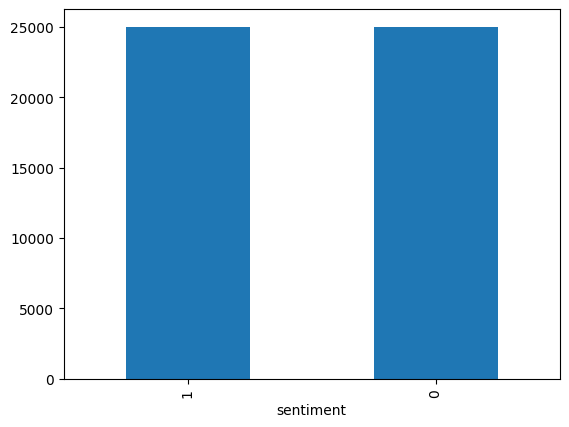

In [14]:
df['sentiment'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'Sentiment Distribution')

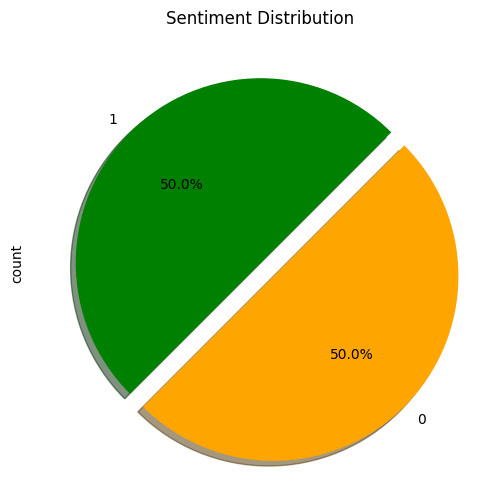

In [15]:
plt.figure(figsize=(10,6))
colors = ['green', 'orange']
df['sentiment'].value_counts().plot(kind='pie', autopct='%.1f%%',shadow = True,colors = colors,startangle = 45,
                 explode=(0, 0.1))
plt.title('Sentiment Distribution')



**Train Test Split**

In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test =train_test_split(df['review'],df['sentiment'],test_size = 0.2,random_state = 42)

In [24]:
X_train

,review
39087,"[that, kept, ask, mani, fight, scream, match, ..."
30893,"[watch, entir, movi, could, watch, entir, movi..."
45278,"[touch, love, stori, reminisc, mood, love, dra..."
16398,"[latterday, fulci, schlocker, total, abysm, co..."
13653,"[first, firmli, believ, norwegian, movi, conti..."
...,...
11284,"[shadow, magic, recaptur, joy, amaz, first, mo..."
44732,"[found, movi, quit, enjoy, fairli, entertain, ..."
38158,"[avoid, one, terribl, movi, excit, pointless, ..."
860,"[product, quit, surpris, absolut, love, obscur..."


**Tokenization**

In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
x_train = tokenizer.texts_to_sequences(X_train)
x_test = tokenizer.texts_to_sequences(X_test)

vocab_size = len(tokenizer.word_index) + 1
maxlen = max(len(x) for x in x_train)

x_train = pad_sequences(x_train, padding='post', maxlen=maxlen)
x_test = pad_sequences(x_test, padding='post', maxlen=maxlen)


x_train

array([[103, 723, 367, ...,   0,   0,   0],
       [ 11, 262,   1, ...,   0,   0,   0],
       [447,  27,  13, ...,   0,   0,   0],
       ...,
       [609,   3, 280, ...,   0,   0,   0],
       [221,  96, 264, ...,   0,   0,   0],
       [469,   1, 202, ...,   0,   0,   0]], dtype=int32)

**CNN Architecture**

In [33]:
from tensorflow.keras.models import Sequential
from keras import layers
from sklearn.metrics import confusion_matrix, classification_report
embedding_dim = 100

model = Sequential()
model.add(layers.Embedding(vocab_size, embedding_dim, input_length=maxlen))
model.add(layers.Conv1D(128, 5, activation='relu'))
model.add(layers.GlobalMaxPooling1D())
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [34]:
history = model.fit(x_train, y_train, epochs=5,batch_size=64,verbose=True, validation_data=(x_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 753s 1s/step - accuracy: 0.8247 - loss: 0.3793 - val_accuracy: 0.8862 - val_loss: 0.2709
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 769s 1s/step - accuracy: 0.9398 - loss: 0.1646 - val_accuracy: 0.8848 - val_loss: 0.2848
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 714s 1s/step - accuracy: 0.9895 - loss: 0.0399 - val_accuracy: 0.8899 - val_loss: 0.3187
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 742s 1s/step - accuracy: 0.9992 - loss: 0.0064 - val_accuracy: 0.8922 - val_loss: 0.3555
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 736s 1s/step - accuracy: 0.9998 - loss: 0.0020 - val_accuracy: 0.8898 - val_loss: 0.3955


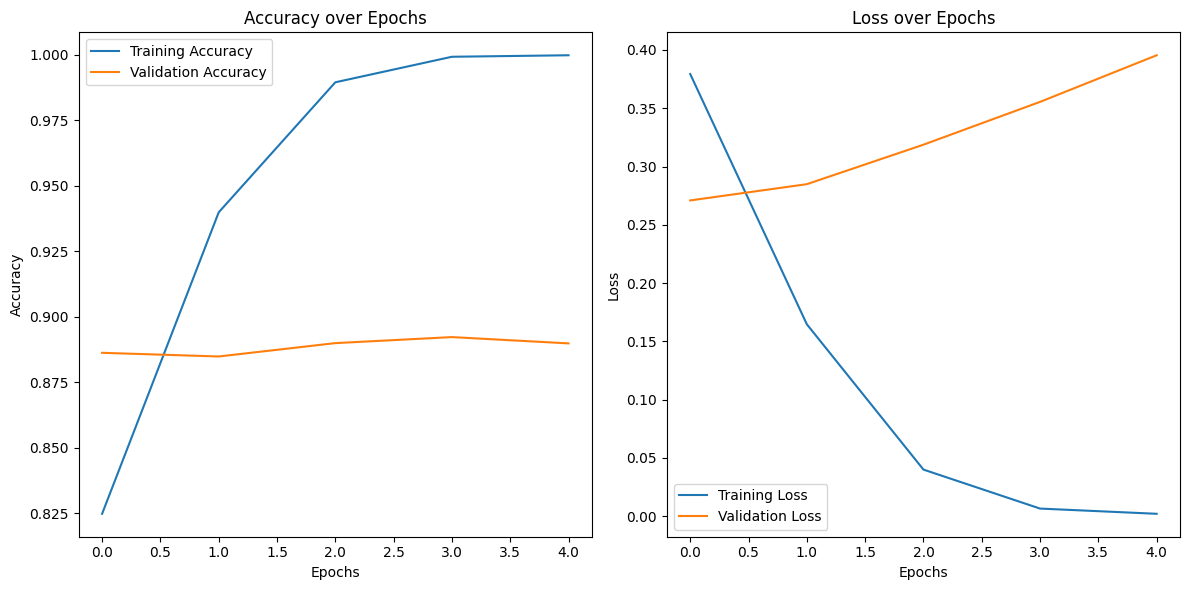

In [35]:
# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

**Confusion and Classification Report**

313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



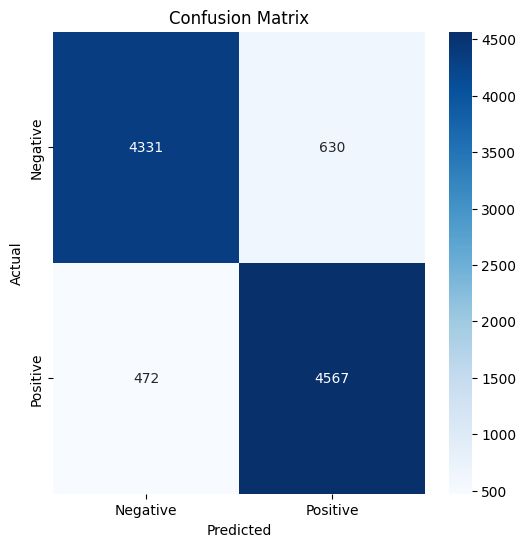

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = (model.predict(x_test) > 0.5).astype(int)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Prediction System**

In [42]:
def predict_sentiment(review,tokenizer, model,maxlen):
  text = clean_review(review)

  sequence = tokenizer.texts_to_sequences([text])
  padded_sequence = pad_sequences(sequence, padding='post', maxlen=maxlen)

  prediction = model.predict(padded_sequence)[0][0]

  if prediction > 0.5:
    return "Positive"
  else:
    return "Negative"

In [44]:
input_text = "it was bad movie"
predict_sentiment(input_text,tokenizer,model,maxlen)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


'Negative'

In [43]:
input_text = "This movie is amazing!"
predict_sentiment(input_text,tokenizer,model,maxlen)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


'Positive'

**Saving the Model**

In [45]:
model.save("cnn_sentiment_model.h5")

import pickle
pickle.dump(tokenizer,open("tokenizer.pkl","wb"))